In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import os

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
os.makedirs('images', exist_ok=True)

conn = sqlite3.connect('loan_data.db')
print("DB 연결 완료!")

DB 연결 완료!


=== 신용등급별 부도율 ===


,loan_grade,총대출건수,부도건수,부도율,평균이자율
0,A,9401,904,9.62,7.35
1,B,9149,1453,15.88,11.00
2,C,5697,1157,20.31,13.45
3,D,3247,1922,59.19,15.35
4,E,870,562,64.60,17.01
5,F,209,146,69.86,18.60
6,G,59,58,98.31,20.25


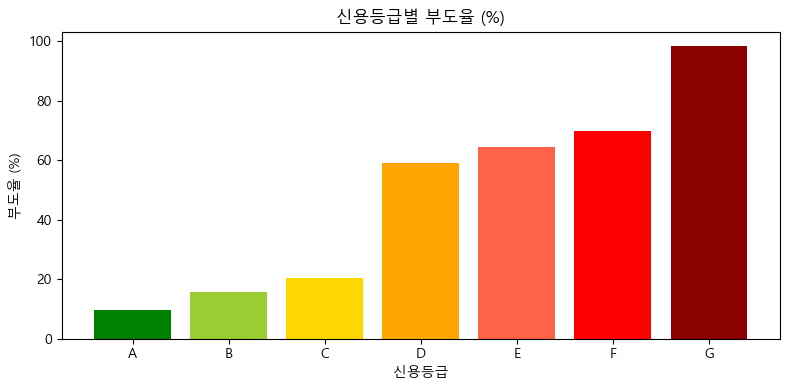

In [2]:
query = """
SELECT 
    l.loan_grade,
    COUNT(*) AS 총대출건수,
    SUM(l.loan_status) AS 부도건수,
    ROUND(AVG(l.loan_status) * 100, 2) AS 부도율,
    ROUND(AVG(l.int_rate), 2) AS 평균이자율
FROM loans l
GROUP BY l.loan_grade
ORDER BY l.loan_grade
"""
df_grade = pd.read_sql(query, conn)
print("=== 신용등급별 부도율 ===")
display(df_grade)

plt.figure(figsize=(8, 4))
plt.bar(df_grade['loan_grade'], df_grade['부도율'],
        color=['green','yellowgreen','gold','orange','tomato','red','darkred'])
plt.title('신용등급별 부도율 (%)')
plt.xlabel('신용등급')
plt.ylabel('부도율 (%)')
plt.tight_layout()
plt.savefig('images/grade_default_rate.png', dpi=150, bbox_inches='tight')
plt.show()

=== 대출 목적별 분석 ===


,대출목적,총건수,평균대출금액,평균이자율,부도율
0,DEBTCONSOLIDATION,4565,9665.0,11.02,28.39
1,MEDICAL,5293,9344.0,11.08,26.85
2,HOMEIMPROVEMENT,3198,10407.0,11.23,25.67
3,PERSONAL,4875,9661.0,11.02,19.73
4,EDUCATION,5702,9520.0,10.98,17.03
5,VENTURE,4999,9644.0,10.98,14.62


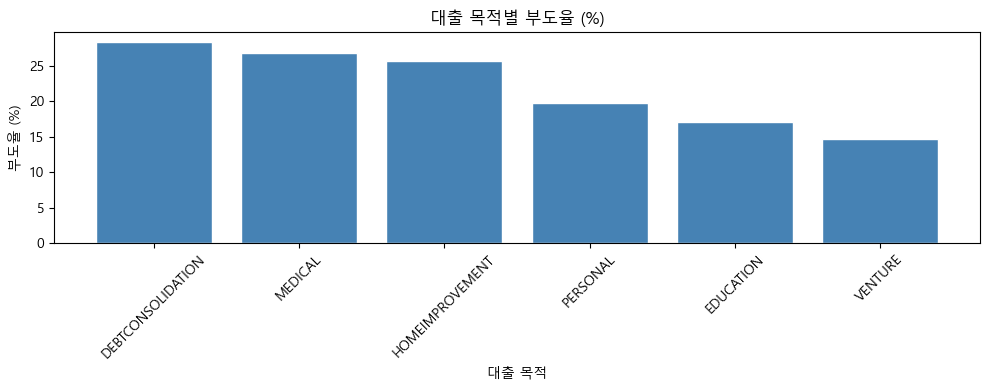

In [3]:
query = """
SELECT
    l.loan_intent AS 대출목적,
    COUNT(*) AS 총건수,
    ROUND(AVG(l.loan_amount), 0) AS 평균대출금액,
    ROUND(AVG(l.int_rate), 2) AS 평균이자율,
    ROUND(AVG(l.loan_status) * 100, 2) AS 부도율
FROM loans l
GROUP BY l.loan_intent
ORDER BY 부도율 DESC
"""
df_intent = pd.read_sql(query, conn)
print("=== 대출 목적별 분석 ===")
display(df_intent)

plt.figure(figsize=(10, 4))
plt.bar(df_intent['대출목적'], df_intent['부도율'], color='steelblue', edgecolor='white')
plt.title('대출 목적별 부도율 (%)')
plt.xlabel('대출 목적')
plt.ylabel('부도율 (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('images/intent_default_rate.png', dpi=150, bbox_inches='tight')
plt.show()

=== 소득 구간별 대출 현황 ===


,소득구간,총건수,평균대출금액,부도율
0,3만달러 미만,3021,5189.0,46.47
1,3~6만달러,12331,8227.0,25.93
2,6~10만달러,9212,11053.0,13.35
3,10만달러 이상,4068,14139.0,9.12


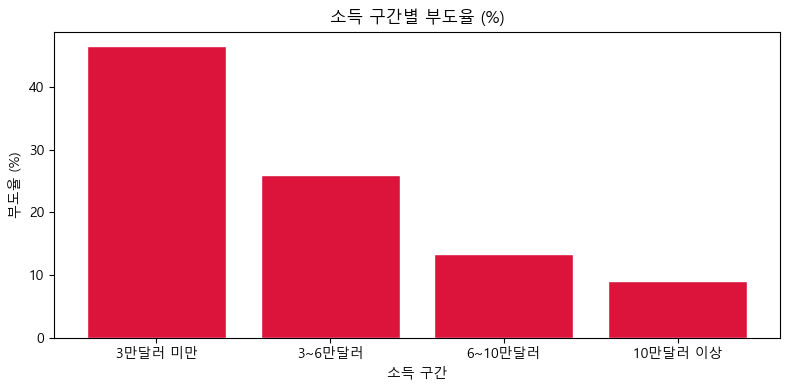

In [4]:
query = """
SELECT
    CASE
        WHEN c.income < 30000 THEN '3만달러 미만'
        WHEN c.income < 60000 THEN '3~6만달러'
        WHEN c.income < 100000 THEN '6~10만달러'
        ELSE '10만달러 이상'
    END AS 소득구간,
    COUNT(*) AS 총건수,
    ROUND(AVG(l.loan_amount), 0) AS 평균대출금액,
    ROUND(AVG(l.loan_status) * 100, 2) AS 부도율
FROM loans l
JOIN customers c ON l.customer_id = c.customer_id
GROUP BY 소득구간
ORDER BY 부도율 DESC
"""
df_income = pd.read_sql(query, conn)
print("=== 소득 구간별 대출 현황 ===")
display(df_income)

plt.figure(figsize=(8, 4))
plt.bar(df_income['소득구간'], df_income['부도율'], color='crimson', edgecolor='white')
plt.title('소득 구간별 부도율 (%)')
plt.xlabel('소득 구간')
plt.ylabel('부도율 (%)')
plt.tight_layout()
plt.savefig('images/income_default_rate.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
query = """
SELECT
    c.customer_id,
    c.age,
    c.income,
    l.loan_amount,
    l.loan_grade,
    l.int_rate,
    l.percent_income,
    l.default_history
FROM loans l
JOIN customers c ON l.customer_id = c.customer_id
WHERE l.loan_grade IN ('D', 'E', 'F', 'G')
AND l.int_rate > 15
AND l.percent_income > 0.3
AND l.default_history = 'Y'
ORDER BY l.int_rate DESC
LIMIT 20
"""
df_highrisk = pd.read_sql(query, conn)
print(f"=== 고위험 고객 TOP 20 ===")
print(f"조건: 신용등급 D~G + 이자율 15% 초과 + 소득대비대출 30% 초과 + 과거부도이력 있음")
display(df_highrisk)

=== 고위험 고객 TOP 20 ===
조건: 신용등급 D~G + 이자율 15% 초과 + 소득대비대출 30% 초과 + 과거부도이력 있음


,customer_id,age,income,loan_amount,loan_grade,int_rate,percent_income,default_history
0,459,23,56000,21600,G,21.21,0.39,Y
1,21130,34,63000,20500,G,20.90,0.33,Y
2,16907,31,36000,13000,E,20.30,0.36,Y
3,16159,29,59000,20000,G,20.17,0.34,Y
4,20363,29,54000,25000,G,20.16,0.46,Y
5,24869,29,60000,25000,G,20.16,0.42,Y
6,1037,24,54000,16750,G,20.11,0.31,Y
7,1088,24,39000,16000,E,19.91,0.41,Y
8,21177,34,70000,22000,E,19.91,0.31,Y
9,14107,23,49000,15000,G,19.82,0.31,Y


In [6]:
print("=" * 55)
print("SQL 분석 종합 인사이트")
print("=" * 55)
print("""
1. 신용등급별 부도율
   - A등급: 부도율 가장 낮음 (우량 고객)
   - G등급: 부도율 가장 높음 → 대출 심사 강화 필요

2. 대출 목적별 부도율
   - 교육/의료 목적 대출이 상대적으로 부도율 높음
   - 부채 통합 목적 대출은 상대적으로 안정적

3. 소득 구간별 현황
   - 저소득층(3만달러 미만)의 부도율이 가장 높음
   - 소득이 높을수록 부도율 낮아지는 경향

4. 고위험 고객 특징
   - D~G등급 + 고이자율 + 소득대비 높은 대출 + 과거부도이력
   - 이 조건 충족 시 집중 모니터링 필요
""")

SQL 분석 종합 인사이트

1. 신용등급별 부도율
   - A등급: 부도율 가장 낮음 (우량 고객)
   - G등급: 부도율 가장 높음 → 대출 심사 강화 필요

2. 대출 목적별 부도율
   - 교육/의료 목적 대출이 상대적으로 부도율 높음
   - 부채 통합 목적 대출은 상대적으로 안정적

3. 소득 구간별 현황
   - 저소득층(3만달러 미만)의 부도율이 가장 높음
   - 소득이 높을수록 부도율 낮아지는 경향

4. 고위험 고객 특징
   - D~G등급 + 고이자율 + 소득대비 높은 대출 + 과거부도이력
   - 이 조건 충족 시 집중 모니터링 필요

